### Multi-Schema
LangGraph默认采用单一共享状态（Single State），所有节点通过一个State读写数据，简单高效，适合中小型工作流  
但当图变得复杂时，单一State容易导致State变得臃肿，容易产生命名冲突、意外覆盖、私有数据泄露等问题  、

MultiSchema的设计理念是“分层控制+边界转换”，MultiSchema能使得：
1. 状态分层与隔离  
    - 不同层级可以使用不同的State Schema
    - 内部节点可以使用更丰富、包含私有字段的Schema，而不需要暴露整个图
2. 子图的模块化与复用
    - 子图可以定义自己独立的输入/输出Schema，与父图完全解耦
    - 通过边界转换器（State Transformer），在进入和退出子图时自动完成字段映射、过滤、转换
3. 清晰的输入输出约定
    - 可以分别为整个Graph定义`input_schema`和`output_schema`
    - 对外可以只暴露必要的字段，隐藏内部中间状态，符合接口隔离原则，提高系统安全性与可维护性
4. 私有状态通道
    - 支持在图内部传递仅部分节点可见的私有数据
    - 避免所有节点共享一个State导致的字段冲突等
5. 提升多代理系统的可控性
    - 在多代理、长周期工作流、嵌套子图等复杂场景下，显著降低状态管理的复杂度

### LangGraph中的Schema层次
- Input Schema
- Output Schema
- Share/Public Schema
- Private Schema
- Internal Runtime Schema


#### 什么是状态驱动Agent？
```text
传统函数链：
Input → f1() → f2() → f3() → Output
         ↑      ↑      ↑
       各自独立，数据通过参数传递，无共享记忆

状态驱动 Agent：
         ┌────────────────────────────┐
         │       Just One State       │
         │  {messages, context, ...}  │
         └──────┬────────┬────────┬───┘
                │modify  │modify  │modify
              Node1     Node2    Node3
```
Core: 所有节点围绕一个‘State’读写，而不相互传参


### 1. Input Schema--系统入口契约
定义调用者必须提供什么
```python
class InputSchema(TypedDict):
    user_id : int
    question: str
```
- - -

### 2. Output Schema--系统出口契约
只暴露调用者需要的最终结果，隐藏所有中间过程
```python
class OutputSchema(TypedDict):
    final_answer : str
```
---

### 3. Shared Schema--全局共享状态
所有节点都能读写的“公共内存”
作用：
  - 存放跨节点必须共享的核心信息
  - 是节点间通信的"主干道"
```python
class SharedSchema(TypedDict):
    messages: str
```
---

### 4. Private Schema--节点私有状态
Private Schema = 节点的"工作草稿区"
作用：
  - 存放只有本节点关心的中间数据
  - 不污染共享State
  - 随节点生命周期创建和销毁
```python
class NodePrivateSchema(TypedDict):
    inner_message : str
```

- - -

### 5. Runtime Schema--运行时动态状态
Runtime Schema = 执行过程中动态生成的临时状态
作用：
  - 记录执行过程中的元信息
  - 用于监控、调试
  - 随一次 invoke() 创建， 结束后丢弃

### 以下是一个多Schema的示例

In [46]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import Literal
import json
import datetime

In [39]:
# 1. define the input schema
class InputSchema(TypedDict):
    user_id: int
    query: str
    session_id: str = "default"

# 2. define the output schema
class OutputSchema(TypedDict):
    final_answer: str
    sources: list[str]
    confidence: float

# 3. Shared Schema - 全局共享状态（主干道）
class SharedSchema(TypedDict):
    messages: Annotated[list, add_messages]   # 对话历史
    user_id: int
    query: str
    intent: str                               # 全局意图
    retrieved_docs: list[dict]                # 检索到的文档

# 4. Runtime Schema - 运行时信息

class RuntimeSchema(TypedDict):
    execution_trace: list[str]          # 执行轨迹
    node_timestamps: dict
    total_tokens: int
    debug_info: dict


# 5. Overall State - 内部真实状态
class OverallState(SharedSchema, RuntimeSchema):

    # SharedSchema
    messages: Annotated[list, add_messages]
    user_id: int
    query: str
    intent: str
    retrieved_docs: list[dict]

    # RuntimeSchema
    execution_trace: list[str]
    node_timestamps: dict
    total_tokens: int
    debug_info: dict

In [48]:
# Node and Private Schema - 各节点以及其私有状态

class ClassifierPrivate(TypedDict):
    """意图分类节点私有"""
    raw_classification: dict
    confidence_scores: dict
    reasoning: str

def classifier_node(state: OverallState) -> ClassifierPrivate:
    print("🔍 classifier_node 执行")
    # 安全更新
    state["execution_trace"].append("classifier")
        
    return {
        "raw_classification": {"type": "technical", "sub_type": "langgraph"},
        "confidence_scores": {"technical": 0.95},
        "reasoning": "用户问题包含 LangGraph MultiSchema 等技术术语"
    }

# ---

class RetrievePrivate(TypedDict):
    """检索节点私有"""
    search_queries: list[str]
    raw_search_results: list[dict]
    selected_indexes: list[int]

def retrieve_node(state: OverallState) -> RetrievePrivate:
    print("📚 retrieve_node 执行")
    state["execution_trace"].append("retrieve")
    
    return {
        "search_queries": [state["query"]],
        "raw_search_results": [{"doc_id": 1, "content": "LangGraph 文档"}],
        "selected_indexes": [0]
    }

# ---

class ReasonerPrivate(TypedDict):
    """深度思考节点私有（多步推理）"""
    thinking_steps: list[str]
    critique: str
    draft_versions: list[str]

def reasoner_node(state: OverallState) -> ReasonerPrivate:
    print("🧠 reasoner_node 执行")
    state["execution_trace"].append("reasoner")
    
    return {
        "thinking_steps": ["分析问题", "整合检索", "构建答案"],
        "critique": "可增加代码示例",
        "draft_versions": ["v1"]
    }

# ---
class ToolPrivate(TypedDict):
    """工具调用节点私有"""
    tool_calls: list[dict]
    tool_results: list[dict]
    tool_errors: list[str]


def tool_node(state: OverallState) -> ToolPrivate:
    print("🛠️ tool_node 执行")
    state["execution_trace"].append("tool")
    
    return {
        "tool_calls": [{"name": "get_user_info"}],
        "tool_results": [{"tier": "premium"}],
        "tool_errors": []
    }


# ---

def final_answer_node(state: OverallState) -> OutputSchema:
    print("✅ final_answer_node 执行")
    state["execution_trace"].append("final_answer")
    
    return {
        "final_answer": "这是关于 LangGraph MultiSchema 的详细回答...",
        "sources": ["langgraph_docs", "api"],
        "confidence": 0.88
    }

In [49]:
# 初始化函数
def initialize_node(state: InputSchema) -> OverallState:
    """必须显式初始化所有 Runtime 字段"""
    print("🔧 初始化运行时状态...")
    return {
        "messages": [],
        "user_id": state.get("user_id"),
        "query": state.get("query"),
        
        "intent": "",
        "retrieved_docs": [],
        "execution_trace": [],         
        "node_timestamps": {},
        "total_tokens": 0,
        "debug_info": {}
    }


In [50]:
builder = StateGraph(
    state_schema=OverallState,
    input_schema=InputSchema,
    output_schema=OutputSchema
)

builder.add_node("initialize", initialize_runtime)
builder.add_node("classifier", classifier_node)
builder.add_node("retrieve", retrieve_node)
builder.add_node("reasoner", reasoner_node)
builder.add_node("tool", tool_node)
builder.add_node("answer", final_answer_node)

builder.add_edge(START, "initialize")
builder.add_edge("initialize", "classifier")
builder.add_edge("classifier", "retrieve")
builder.add_edge("retrieve", "reasoner")
builder.add_edge("reasoner", "tool")
builder.add_edge("tool", "answer")
builder.add_edge("answer", END)



In [51]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

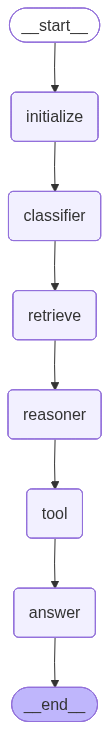

In [44]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [52]:
config = {
    'configurable':{
        'thread_id':'user_8888'
    }
}
result = graph.invoke({
    "user_id": 88888,
    "query": "如何在 LangGraph 中实现复杂的 MultiSchema 架构？",
    "session_id": "sess_2026"
}, config = config)

print("\n=== 最终返回给用户的输出 ===")
print(json.dumps(result, indent=2, ensure_ascii=False))

🔍 classifier_node 执行
📚 retrieve_node 执行
🧠 reasoner_node 执行
🛠️ tool_node 执行
✅ final_answer_node 执行

=== 最终返回给用户的输出 ===
{
  "final_answer": "这是关于 LangGraph MultiSchema 的详细回答...",
  "sources": [
    "langgraph_docs",
    "api"
  ],
  "confidence": 0.88
}


In [53]:
# ==================== 查看完整内部状态 ====================
full_state = graph.get_state(config)

In [54]:
print("2. 图内部所有可用字段及其实际值")
print("="*60)

for key, value in full_state.values.items():
    if value is not None and (isinstance(value, (list, dict)) or value != ""):
        print(f"\n【{key}】:")
        if isinstance(value, dict):
            print(json.dumps(value, indent=2, ensure_ascii=False))
        elif isinstance(value, list):
            print(value)
        else:
            print(value)

2. 图内部所有可用字段及其实际值

【messages】:
[]

【user_id】:
88888

【query】:
如何在 LangGraph 中实现复杂的 MultiSchema 架构？

【retrieved_docs】:
[]

【execution_trace】:
[]

【node_timestamps】:
{}

【total_tokens】:
0

【debug_info】:
{}

【session_id】:
sess_2026

【final_answer】:
这是关于 LangGraph MultiSchema 的详细回答...

【sources】:
['langgraph_docs', 'api']

【confidence】:
0.88


In [ ]:
"""
LangGraph Multi-Schema 示例
============================
演示如何在同一个图中为不同节点/子图使用不同的状态 Schema。

核心概念：
- StateGraph 的 input/output schema 与内部 state schema 可以分离
- 子图（subgraph）可以拥有完全独立的 schema
- PrivateState 用于节点间传递临时数据，对外不可见

安装依赖：
    pip install langgraph langchain_core
"""

from typing import TypedDict, Annotated, Optional
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
import operator


# ============================================================
# 示例 1：Input / Output Schema 与内部 State 分离
# ============================================================

class InputSchema(TypedDict):
    """用户输入的 schema —— 只暴露给调用方的字段"""
    user_query: str
    language: str


class OutputSchema(TypedDict):
    """最终输出的 schema —— 只返回给调用方的字段"""
    final_answer: str
    confidence: float


class InternalState(TypedDict):
    """图内部完整 state —— 包含所有中间数据"""
    # 来自 InputSchema
    user_query: str
    language: str
    # 中间处理数据（对外不可见）
    parsed_intent: Optional[str]
    retrieved_context: Optional[str]
    draft_answer: Optional[str]
    # 最终输出（映射到 OutputSchema）
    final_answer: Optional[str]
    confidence: Optional[float]


def parse_intent_node(state: InternalState) -> dict:
    """解析用户意图（内部节点，使用完整 InternalState）"""
    query = state["user_query"]
    # 模拟意图解析
    if "天气" in query or "weather" in query.lower():
        intent = "weather_query"
    elif "翻译" in query or "translate" in query.lower():
        intent = "translation"
    else:
        intent = "general_qa"
    print(f"[parse_intent] 识别意图: {intent}")
    return {"parsed_intent": intent}


def retrieve_context_node(state: InternalState) -> dict:
    """检索上下文（内部节点）"""
    intent = state.get("parsed_intent", "general_qa")
    context_map = {
        "weather_query": "当前天气数据：北京 25°C 晴",
        "translation": "翻译引擎就绪，支持中英互译",
        "general_qa": "通用知识库已加载",
    }
    context = context_map.get(intent, "")
    print(f"[retrieve_context] 检索到上下文: {context}")
    return {"retrieved_context": context}


def generate_answer_node(state: InternalState) -> dict:
    """生成回答（内部节点）"""
    query = state["user_query"]
    context = state.get("retrieved_context", "")
    lang = state.get("language", "zh")

    if lang == "en":
        draft = f"Based on '{context}', the answer to '{query}' is: [Generated Answer]"
    else:
        draft = f"根据「{context}」，针对「{query}」的回答是：[生成的回答]"

    print(f"[generate_answer] 草稿: {draft}")
    return {"draft_answer": draft, "final_answer": draft, "confidence": 0.92}


# 构建使用分离 Schema 的图
def build_separated_schema_graph():
    graph = StateGraph(
        InternalState,
        input=InputSchema,   # 只接受 InputSchema 中的字段作为输入
        output=OutputSchema, # 只返回 OutputSchema 中的字段作为输出
    )

    graph.add_node("parse_intent", parse_intent_node)
    graph.add_node("retrieve_context", retrieve_context_node)
    graph.add_node("generate_answer", generate_answer_node)

    graph.add_edge(START, "parse_intent")
    graph.add_edge("parse_intent", "retrieve_context")
    graph.add_edge("retrieve_context", "generate_answer")
    graph.add_edge("generate_answer", END)

    return graph.compile()


# ============================================================
# 示例 2：带 Private State 的节点间数据传递
# ============================================================

class PublicState(TypedDict):
    """对外可见的状态"""
    messages: Annotated[list[BaseMessage], add_messages]
    summary: Optional[str]


class PrivateState(TypedDict):
    """节点私有状态 —— 仅在节点链内部传递，不进入主 state"""
    messages: Annotated[list[BaseMessage], add_messages]  # 从 PublicState 继承
    # 私有字段
    raw_tokens: Optional[list[str]]
    intermediate_score: Optional[float]


def tokenize_node(state: PublicState) -> PrivateState:
    """将公共消息 token 化，结果存入私有状态"""
    messages = state.get("messages", [])
    all_text = " ".join([m.content for m in messages])
    tokens = all_text.split()
    print(f"[tokenize] token 数量: {len(tokens)}")
    # 返回 PrivateState 格式
    return {"messages": messages, "raw_tokens": tokens, "intermediate_score": None}


def score_node(state: PrivateState) -> PrivateState:
    """基于私有状态中的 tokens 计算分数"""
    tokens = state.get("raw_tokens", [])
    score = min(len(tokens) / 100.0, 1.0)  # 简单示例分数
    print(f"[score] 计算得分: {score:.2f}")
    return {**state, "intermediate_score": score}


def summarize_node(state: PrivateState) -> PublicState:
    """生成摘要，结果写回公共状态"""
    score = state.get("intermediate_score", 0)
    tokens = state.get("raw_tokens", [])
    summary = f"对话包含 {len(tokens)} 个词，质量分数: {score:.2f}"
    print(f"[summarize] 摘要: {summary}")
    # 只返回 PublicState 中的字段
    return {"summary": summary}


def build_private_state_graph():
    # 注意：这里用 PublicState 作为主图 schema
    graph = StateGraph(PublicState)

    graph.add_node("tokenize", tokenize_node)
    graph.add_node("score", score_node)
    graph.add_node("summarize", summarize_node)

    graph.add_edge(START, "tokenize")
    graph.add_edge("tokenize", "score")
    graph.add_edge("score", "summarize")
    graph.add_edge("summarize", END)

    return graph.compile()


# ============================================================
# 示例 3：子图（Subgraph）拥有完全独立的 Schema
# ============================================================

# --- 子图的独立 Schema ---
class SubgraphInput(TypedDict):
    text: str


class SubgraphOutput(TypedDict):
    processed_text: str
    word_count: int


class SubgraphState(TypedDict):
    text: str
    cleaned_text: Optional[str]
    processed_text: Optional[str]
    word_count: Optional[int]


# 子图节点
def clean_text_node(state: SubgraphState) -> dict:
    text = state["text"].strip().lower()
    print(f"  [subgraph/clean] '{text[:30]}...'")
    return {"cleaned_text": text}


def process_text_node(state: SubgraphState) -> dict:
    cleaned = state.get("cleaned_text", "")
    words = cleaned.split()
    processed = " ".join(w.capitalize() for w in words)
    print(f"  [subgraph/process] 词数: {len(words)}")
    return {"processed_text": processed, "word_count": len(words)}


def build_text_subgraph():
    """构建一个独立 schema 的子图"""
    sg = StateGraph(SubgraphState, input=SubgraphInput, output=SubgraphOutput)
    sg.add_node("clean", clean_text_node)
    sg.add_node("process", process_text_node)
    sg.add_edge(START, "clean")
    sg.add_edge("clean", "process")
    sg.add_edge("process", END)
    return sg.compile()


# --- 主图的 Schema ---
class MainState(TypedDict):
    raw_input: str
    processed_text: Optional[str]  # 接收子图输出
    word_count: Optional[int]       # 接收子图输出
    final_report: Optional[str]


def prepare_node(state: MainState) -> dict:
    """主图节点：准备数据"""
    print(f"[main/prepare] 原始输入长度: {len(state['raw_input'])}")
    return {}


def report_node(state: MainState) -> dict:
    """主图节点：生成最终报告"""
    report = (
        f"处理结果：{state.get('processed_text', '')}\n"
        f"词汇数量：{state.get('word_count', 0)}"
    )
    print(f"[main/report] {report}")
    return {"final_report": report}


def build_main_graph_with_subgraph():
    """主图嵌套子图，schema 完全独立"""
    text_subgraph = build_text_subgraph()

    # 子图的 input/output 字段需要与主图 state 字段对应
    main = StateGraph(MainState)
    main.add_node("prepare", prepare_node)

    # 嵌入子图：自动映射 raw_input -> text（子图 input），
    # processed_text/word_count <- 子图 output
    main.add_node("text_processor", text_subgraph)

    main.add_node("report", report_node)

    main.add_edge(START, "prepare")
    main.add_edge("prepare", "text_processor")
    main.add_edge("text_processor", "report")
    main.add_edge("report", END)

    return main.compile()


# ============================================================
# 运行所有示例
# ============================================================

if __name__ == "__main__":
    print("=" * 60)
    print("示例 1：Input/Output Schema 与内部 State 分离")
    print("=" * 60)
    app1 = build_separated_schema_graph()
    result1 = app1.invoke({
        "user_query": "今天北京天气怎么样？",
        "language": "zh"
    })
    print(f"输出 (只含 OutputSchema 字段): {result1}\n")


    print("=" * 60)
    print("示例 2：Private State 节点间数据传递")
    print("=" * 60)
    app2 = build_private_state_graph()
    result2 = app2.invoke({
        "messages": [
            HumanMessage(content="你好，请介绍一下 LangGraph 的多 Schema 用法"),
            AIMessage(content="LangGraph 支持为不同节点定义独立的状态 schema，实现数据隔离"),
        ]
    })
    print(f"输出 (只含 PublicState 字段): {result2}\n")


    print("=" * 60)
    print("示例 3：子图拥有独立 Schema")
    print("=" * 60)
    app3 = build_main_graph_with_subgraph()
    result3 = app3.invoke({
        "raw_input": "  hello world this is a langgraph multischema demo  "
    })
    print(f"输出: {result3}\n")

    print("所有示例运行完毕 ✓")